In [1]:
# COMMAND To delete folder. (use carefully)
# os.system("rm -rf /content/encryption_decryption")
# os.system("rm -rf /content/quantum_images")

In [2]:
# # to download folder
# from google.colab import files
# import shutil

# folder_path = "encryption_decryption"   #change this to your folder
# zip_path = folder_path + ".zip"

# # Create ZIP
# shutil.make_archive(folder_path, 'zip', folder_path)

# # Download ZIP
# files.download(zip_path)


In [3]:
!pip install sewar

  Preparing metadata (setup.py) ... done
  Created wheel for sewar: filename=sewar-0.4.6-py3-none-any.whl size=11418 sha256=1d61f9c1d8f0f7fafd159471a9934bf4c4f770e354882bb59a303d9c31442d27
  Stored in directory: /root/.cache/pip/wheels/fb/4e/29/b15a3d425c5f0fe8f461cbfdaf4fa98ef203fed97ce1df6695
Successfully built sewar


In [4]:
import sys
# set_printoptions(threshold=sys.maxsize)
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
from sewar.full_ref import mse, rmse, psnr, uqi, ssim, ergas, scc, rase, sam, msssim, vifp
from matplotlib import pyplot as plt
import os
import numpy as np
import random
import pandas as pd
from skimage import io
import time
import hashlib
from scipy.integrate import odeint
import re

In [5]:
# !wget https://i.ibb.co/GxhRPnC/lake-512.jpg -O lake.jpg
# !wget https://i.ibb.co/D18bYP1/peppers-color.jpg -O peppers.jpg
# !wget https://i.ibb.co/2dckpJ9/mandril-color.jpg -O mandril.jpg

In [6]:
# Specify the folder name
folder_path = "images"

# Get the list of files in the 'images' folder
files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Print the list of files
print(files)

['img1.png']


In [7]:
######################## CREATING SUPERPOSITION STATES ###################################################################

def convert (H,i_state):
    cov = np.dot(H,i_state)
    si = cov
    alpha=si[0][0]
    beta=si[1][0]
    return [alpha,beta]

In [8]:
def conv_img(img):
    small = img
    H = np.array([[1,0],[0,1]])
    converted = np.zeros((256,512))
    img = small
    list_st=[]
    for i in range(0,len(img)) :
      for j in range(0,len(img[0])):
        a = img[i][j]
        a1= np.sqrt(a/255)
        b= 255 - a
        a2 = np.sqrt(b/255)
        i_state= np.array([[a2],[a1]])
        c = convert(H,i_state)
        list_st+=[c[0]**2 + c[1]**2]
        converted [i][2*j] = c[0]*255
        converted [i][2*j+1] = c[1]*255

    return converted

def conv_rgb(img):
    b, g, r    = img[:, :, 0], img[:, :, 1], img[:, :, 2]
    b1, g1, r1 = conv_img(b), conv_img(g), conv_img(r)
    img = cv2.resize(img,(512,256))
    img[:,:,0], img[:,:,1], img[:,:,2] = b1, g1, r1
    return img

In [9]:
# Ensure the 'quantum_images' folder exists
output_folder = "quantum_images"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

img1.png


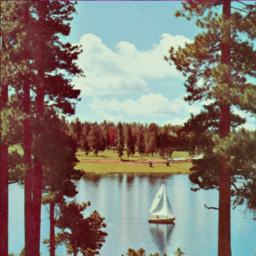

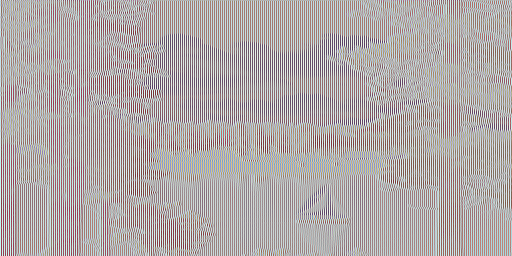

In [10]:
df = pd.DataFrame()
for filey in files:
  file_path = os.path.join(folder_path, filey)
  img = cv2.imread(file_path)
  print(filey)
  new1 = cv2.resize(img,(256,256))
  cv2_imshow(new1)
  conv2=conv_rgb(new1)
  cv2_imshow(conv2)
  # Save the conv2 image to the 'quantum_images' folder
  output_file_path = os.path.join(output_folder, f"quantum_{filey}")
  cv2.imwrite(output_file_path, conv2)

In [11]:
############ LORENZ #############

In [12]:
# Function to create folders if they don't exist
def ensure_folder_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder created: {folder_path}")
    else:
        print(f"Folder already exists: {folder_path}")

In [13]:
# Lorenz system and shuffle image logic

####################### LORENZ SHUFFLING CODE INSERTION ############################
# Lorenz system differential equations

def lorenz_system(x, y, z, sigma=10, beta=8/3, rho=28, dt=0.01, steps=10000):
    """
    Generates a chaotic sequence using the Lorenz system.

    Returns:
        indices: A list of shuffled indices.
    """
    trajectory = []
    for _ in range(steps):
        dx = sigma * (y - x) * dt
        dy = (x * (rho - z) - y) * dt
        dz = (x * y - beta * z) * dt
        x += dx
        y += dy
        z += dz
        trajectory.append((x, y, z))

    # Normalize and convert trajectory into index positions
    trajectory = np.array(trajectory)
    norm_x = np.argsort(trajectory[:, 0])  # Sorting based on X generates shuffled indices
    return norm_x

# Function to shuffle pixels using lorenz system
def shuffle_image(image):
    """
    Shuffles the pixels of an image using the Lorenz system.

    Returns:
        Shuffled image and the Lorenz indices for unshuffling.
    """
    h, w, c = image.shape
    pixels = image.reshape(-1, c)  # Flatten image into a pixel list
    indices = lorenz_system(0.1, 0.1, 0.1, steps=len(pixels))  # Generate chaotic indices
    print("indices = ", indices)

    shuffled_pixels = pixels[indices]  # Apply shuffle
    shuffled_image = shuffled_pixels.reshape(h, w, c)  # Reshape back to image format

    return shuffled_image, indices

In [14]:
# Generation of shuffled image using Lorenz system

def process_quantum_images(input_folder, output_folder):

    # Ensure the output folder exists
    ensure_folder_exists(output_folder)

    # Iterate through quantum images in the input folder
    for file_name in os.listdir(input_folder):

        # Accept files like: quantum_img1.png, quantum_something.jpg, quantum_xyz.jpeg
        if file_name.startswith("quantum_") and file_name.endswith((".png", ".jpg", ".jpeg")):

            # Extract the identifier after 'quantum_'
            # Example: quantum_img1.png -> img1
            img_id = file_name.split("quantum_")[-1].split('.')[0]

            # Full path of input quantum image
            quantum_image_path = os.path.join(input_folder, file_name)

            # Load the quantum image
            img = cv2.imread(quantum_image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Shuffle the image (using your shuffle logic)
            shuffled_img, indices = shuffle_image(img)

            # Save shuffled output file
            shuffled_filename = f"shuffled_img_{img_id}.png"
            shuffled_filepath = os.path.join(output_folder, shuffled_filename)

            cv2.imwrite(shuffled_filepath, shuffled_img)

            print(f"Shuffled image saved: {shuffled_filepath}")


# Input and output folders
quantum_images_folder = os.path.join("quantum_images")
shuffled_images_folder = os.path.join("encryption_decryption", "shuffled_images")

# Ensure shuffled_images folder exists
ensure_folder_exists(shuffled_images_folder)

# Process quantum images and store shuffled versions
process_quantum_images(quantum_images_folder, shuffled_images_folder)


Folder created: encryption_decryption/shuffled_images
Folder already exists: encryption_decryption/shuffled_images
indices =  [15230 41650 41649 ...    57    55    56]
Shuffled image saved: encryption_decryption/shuffled_images/shuffled_img_img1.png


In [15]:

# Folders
shuffled_folder = "encryption_decryption/shuffled_images"
quantum_folder = "quantum_images"
output_folder = "encryption_decryption/xor_shuffled_quantum"

# Ensure output folder exists
os.makedirs(output_folder, exist_ok=True)

# Get image lists
shuffled_list = sorted(os.listdir(shuffled_folder))
quantum_list = sorted(os.listdir(quantum_folder))

print("Shuffled images:", shuffled_list)
print("Quantum images:", quantum_list)

# Process each shuffled image
for img_name in shuffled_list:

    # Skip checkpoints
    if img_name == ".ipynb_checkpoints":
        continue

    # Extract image ID
    img_id = img_name.split("_")[-1].split(".")[0]

    quantum_name = f"quantum_{img_id}.png"
    quantum_path = os.path.join(quantum_folder, quantum_name)

    # Skip if matching quantum image does not exist
    if not os.path.exists(quantum_path):
        print(f"❌ Quantum image not found for {img_name}, skipping.")
        continue

    # Full paths
    shuffled_path = os.path.join(shuffled_folder, img_name)

    # Load images
    shuffled_img = np.array(Image.open(shuffled_path))
    quantum_img = np.array(Image.open(quantum_path))

    # Ensure size match
    if shuffled_img.shape != quantum_img.shape:
        print(f"⚠️ Size mismatch for img_id={img_id}, skipping.")
        continue

    # Perform XOR
    xor_result = np.bitwise_xor(shuffled_img, quantum_img)

    # Save XOR output
    result_img = Image.fromarray(xor_result)
    out_path = os.path.join(output_folder, f"xor_sq_{img_id}.png")
    result_img.save(out_path)

    print(f"✔ XOR saved: {out_path}")

print("\nXOR between shuffled & quantum images — COMPLETED.")


Shuffled images: ['shuffled_img_img1.png']
Quantum images: ['quantum_img1.png']
✔ XOR saved: encryption_decryption/xor_shuffled_quantum/xor_sq_img1.png

XOR between shuffled & quantum images — COMPLETED.


In [16]:
# 4×4 Blockwise Quantum-Inspired Rotation Gate

import numpy as np
import math

def rotation_gate(theta):
    return np.array([
        [math.cos(theta), -math.sin(theta)],
        [math.sin(theta),  math.cos(theta)]
    ], dtype=np.float32)

def rotate_block_4x4(block, theta):
    """Apply quantum-inspired rotation to 4×4 grayscale block"""
    R = rotation_gate(theta)
    rotated = np.zeros_like(block, dtype=np.float32)

    for i in range(4):
        row = block[i].astype(np.float32)

        # Split into two 2D pairs: (0,1) & (2,3)
        p1 = row[:2]
        p2 = row[2:]

        rotated[i, :2] = R @ p1
        rotated[i, 2:] = R @ p2

    return np.clip(rotated, 0, 255).astype(np.uint8)

def blockwise_rotation(image, theta_degrees):
    """Apply 4×4 blockwise quantum rotation to the entire image."""
    theta = math.radians(theta_degrees)
    h, w = image.shape

    pad_h = (4 - (h % 4)) % 4
    pad_w = (4 - (w % 4)) % 4

    padded_image = np.pad(image, ((0, pad_h), (0, pad_w)), mode='reflect')
    rotated_output = np.zeros_like(padded_image)

    H, W = padded_image.shape

    for i in range(0, H, 4):
        for j in range(0, W, 4):
            block = padded_image[i:i+4, j:j+4]
            rotated_output[i:i+4, j:j+4] = rotate_block_4x4(block, theta)

    return rotated_output[:h, :w]


In [17]:
# PERTURBATION
def add_quantum_perturbation(img, delta=2):
    """
    Simulates quantum energy-loss perturbation.
    Adds tiny random noise to each pixel.
    """
    noisy = img.astype(np.int16)

    noise = np.random.uniform(-delta, delta, img.shape)
    noisy = noisy + noise

    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)


In [18]:
# ======================================================
# APPLY 4×4 BLOCKWISE QUANTUM ROTATION TO SHUFFLED IMAGES
# ======================================================

def process_shuffled_images_for_rotation(input_folder, output_folder, theta=45):

    ensure_folder_exists(output_folder)

    for file_name in os.listdir(input_folder):

        # Match shuffled image names: shuffled_img_xxx.png
        if file_name.startswith("shuffled_img_") and file_name.endswith((".png", ".jpg", ".jpeg")):

            img_id = file_name.split("shuffled_img_")[-1].split('.')[0]

            # Load shuffled image
            shuffled_path = os.path.join(input_folder, file_name)
            img = Image.open(shuffled_path).convert("RGB")
            img_np = np.array(img)     # Convert to NumPy array

            # Prepare empty rotated output
            rotated_channels = []

            # Apply 4×4 blockwise rotation ON EACH CHANNEL SEPARATELY
            for c in range(3):
                channel = img_np[:, :, c]
                rotated_c = blockwise_rotation(channel, theta)
                rotated_channels.append(rotated_c)

            # Merge rotated R, G, B
            rotated_img = np.stack(rotated_channels, axis=2)

            rotated_img = add_quantum_perturbation(rotated_img, delta=2)

            # Save rotated output
            output_filename = f"rotated_{img_id}.png"
            output_filepath = os.path.join(output_folder, output_filename)

            cv2.imwrite(output_filepath, cv2.cvtColor(rotated_img, cv2.COLOR_RGB2BGR))

            print(f"Rotated image saved: {output_filepath}")


# FOLDERS
shuffled_images_folder = os.path.join("encryption_decryption", "shuffled_images")
rotated_images_folder  = os.path.join("encryption_decryption", "rotated_images")

ensure_folder_exists(rotated_images_folder)

# Execute rotation
process_shuffled_images_for_rotation(shuffled_images_folder, rotated_images_folder, theta=25)

Folder created: encryption_decryption/rotated_images
Folder already exists: encryption_decryption/rotated_images
Rotated image saved: encryption_decryption/rotated_images/rotated_img1.png


In [19]:
# Hyperchaotic image generation

# Hyper-chaotic system function
def d5_Eq(p, t):
    a, b = 23, 3
    c, m = 18, 12
    h = 4
    dxdt = a * p[1] - a * p[0]
    dydt = (c - a) * p[0] + c * p[1] + p[4] - p[0] * p[2]
    dzdt = -b * p[2] + p[0] * p[1]
    dudt = m * p[4]
    dvdt = - p[1] - h * p[3]
    dpdt = [dxdt, dydt, dzdt, dudt, dvdt]
    return dpdt

def extract_single_col(pp, i, row, col):
    ll = []
    for item in pp:
        ll.append(item[i])
    ll = np.array(ll)
    ll.resize(row, col)
    return ll

def generate_numbers(key, mean_image):
    data = mean_image.flatten().astype(np.float64)
    data_bytes = data.tobytes()

    salt = hashlib.sha256(key.encode()).hexdigest()
    hash_object = hashlib.sha256(data_bytes + salt.encode())
    hash_bytes = hash_object.digest()

    random.seed(int.from_bytes(hash_bytes, byteorder='big'))
    random_floats = [random.uniform(-0.1, 0.1) for _ in range(5)]

    combined_values = random_floats + [int.from_bytes(hash_bytes, byteorder='big') / 2 ** 256]
    return [round(x, 9) for x in combined_values[:5]]

In [20]:
def process_and_generate_hyperchaotic_image(rotated_image_path, quantum_image_path, output_folder, image_id):

    ensure_folder_exists(output_folder)

    # Load rotated image
    rotated_img = cv2.imread(rotated_image_path)
    if rotated_img is None:
        print(f"Error: Could not read rotated image {rotated_image_path}")
        return

    rotated_img = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)

    (R, G, B) = cv2.split(rotated_img)
    row, col, _ = rotated_img.shape

    # Load corresponding quantum image
    if not os.path.isfile(quantum_image_path):
        print(f"Warning: Skipping missing quantum file: {quantum_image_path}")
        return

    quantum_img = Image.open(quantum_image_path)
    mean_image = np.mean(np.array(quantum_img))

    # --- hyperchaotic system ---
    key = "kn$9t3rt5%eml@Z71!@#$5q&*90AsD$x"
    p0 = generate_numbers(key, mean_image)

    t = np.linspace(0, 100, 1000000 + 196608)
    p = odeint(d5_Eq, p0, t)
    pp = np.absolute(p[1000000:, :] * 10000000)
    pp = np.array(pp % 256, dtype=np.uint8)

    # Extract chaotic keys
    k1 = extract_single_col(pp, 0, row, col)
    k2 = extract_single_col(pp, 1, row, col)
    k3 = extract_single_col(pp, 2, row, col)
    k4 = extract_single_col(pp, 3, row, col)
    k5 = extract_single_col(pp, 4, row, col)

    k123 = k1 ^ k2 ^ k3
    k234 = k2 ^ k3 ^ k4
    k345 = k3 ^ k4 ^ k5

    # Final hyperchaotic image
    hyperchaotic_image = np.zeros((row, col, 3), dtype=np.uint8)
    hyperchaotic_image[:, :, 0] = k123
    hyperchaotic_image[:, :, 1] = k234
    hyperchaotic_image[:, :, 2] = k345

    output_path = os.path.join(output_folder, f"hyperchaotic_{image_id}.png")
    cv2.imwrite(output_path, hyperchaotic_image)

    print(f"Hyperchaotic image saved: {output_path}")




rotated_images_folder = os.path.join("encryption_decryption", "rotated_images")
quantum_images_folder = os.path.join("quantum_images")
hyperchaotic_images_folder = os.path.join("encryption_decryption", "hyperchaotic_images")

ensure_folder_exists(hyperchaotic_images_folder)

# Process only valid rotated files
rotated_images = [
    f for f in os.listdir(rotated_images_folder)
    if f.startswith("rotated_") and f.endswith((".png", ".jpg", ".jpeg")) and not f.startswith(".")
]

rotated_images.sort()  # ensure correct order

for rotated_image_name in rotated_images:

    img_id = rotated_image_name.split("rotated_")[-1].split('.')[0]

    rotated_image_path = os.path.join(rotated_images_folder, rotated_image_name)
    quantum_image_path = os.path.join(quantum_images_folder, f"quantum_{img_id}.png")

    # Verify rotated exists
    if not os.path.isfile(rotated_image_path):
        print(f"Warning: Rotated file not found: {rotated_image_path}")
        continue

    # Missing quantum image
    if not os.path.isfile(quantum_image_path):
        print(f"Warning: Quantum image missing for ID {img_id}: {quantum_image_path}")
        continue

    # Process
    process_and_generate_hyperchaotic_image(
        rotated_image_path,
        quantum_image_path,
        hyperchaotic_images_folder,
        img_id
    )


Folder created: encryption_decryption/hyperchaotic_images
Folder already exists: encryption_decryption/hyperchaotic_images
Hyperchaotic image saved: encryption_decryption/hyperchaotic_images/hyperchaotic_img1.png


In [21]:

# Final Encryption of the Image


# Input folders
rotated_images_folder = os.path.join("encryption_decryption", "rotated_images")
hyperchaotic_images_folder = os.path.join("encryption_decryption", "hyperchaotic_images")
final_encryption_folder = os.path.join("encryption_decryption", "final_encryption")

# Ensure output folder exists
ensure_folder_exists(final_encryption_folder)

# Filter only valid rotated images
rotated_images = [
    f for f in os.listdir(rotated_images_folder)
    if f.startswith("rotated_") and f.endswith((".png", ".jpg", ".jpeg")) and not f.startswith(".")
]

# Sort for consistency
rotated_images.sort()


for rotated_img_name in rotated_images:

    # Extract ID from rotated image name: rotated_{id}.png
    img_id = rotated_img_name.split("rotated_")[-1].split('.')[0]

    rotated_image_path = os.path.join(rotated_images_folder, rotated_img_name)
    hyperchaotic_image_path = os.path.join(hyperchaotic_images_folder, f"hyperchaotic_{img_id}.png")

    # Check hyperchaotic image existence
    if not os.path.isfile(hyperchaotic_image_path):
        print(f"Warning: Missing hyperchaotic image for ID {img_id}, skipping.")
        continue

    # Load images
    img_rotated = Image.open(rotated_image_path).convert("RGB")
    img_hyper = Image.open(hyperchaotic_image_path).convert("RGB")

    # Convert to arrays
    arr_rotated = np.array(img_rotated)
    arr_hyper = np.array(img_hyper)

    # XOR operation
    encrypted_arr = np.bitwise_xor(arr_rotated, arr_hyper)

    # Convert back to image
    encrypted_img = Image.fromarray(encrypted_arr)

    # Save encrypted image
    output_path = os.path.join(final_encryption_folder, f"encrypted_{img_id}.png")
    encrypted_img.save(output_path)

    print(f"Encrypted image saved: {output_path}")



Folder created: encryption_decryption/final_encryption
Encrypted image saved: encryption_decryption/final_encryption/encrypted_img1.png


In [22]:
#################### Measurement Operation #############################################

In [23]:
import cv2
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt
import os
import numpy as np
import random
import glob

In [24]:
def measure_quantum_image(converted_img, measurement_count=1):
    height, width = converted_img.shape
    original_width = width // 2
    measured_results = np.zeros((height, original_width, measurement_count))

    # Seed the random number generator for each measurement to ensure variability
    for m in range(measurement_count):
        np.random.seed(m + 42)  # Different seed for each measurement
        for i in range(height):
            for j in range(original_width):
                # Get the two adjacent pixel values
                alpha = converted_img[i, 2*j] / 255.0
                beta = converted_img[i, 2*j+1] / 255.0

                # Calculate probabilities based on the quantum amplitudes
                # Since encoding calculates alpha = sqrt(1-brightness/255) and beta = sqrt(brightness/255)
                # For retrieval, probability of |0⟩ is alpha^2 and |1⟩ is beta^2
                prob_0 = alpha * alpha
                prob_1 = beta * beta

                # Normalize probabilities if they don't sum to 1 (due to numerical issues)
                total_prob = prob_0 + prob_1
                if total_prob > 0:
                    prob_0 /= total_prob
                    prob_1 /= total_prob
                else:
                    prob_0 = prob_1 = 0.5

                # Random selection based on probability
                if np.random.random() < prob_1:  # Choose |1⟩ state with probability beta^2
                    # |1⟩ state corresponds to the original pixel value
                    value = 255  # Maximum brightness
                else:
                    # |0⟩ state corresponds to the absence of the original pixel value
                    value = 0    # Minimum brightness

                # Store this measurement result
                measured_results[i, j, m] = value

    # Average the measurements
    measured_img = np.mean(measured_results, axis=2)

    # Ensure values are in valid range
    measured_img = np.clip(measured_img, 0, 255)

    return measured_img

def decode_rgb(quantum_img, measurement_count=1):

    # Split into channels
    b, g, r = quantum_img[:, :, 0], quantum_img[:, :, 1], quantum_img[:, :, 2]

    # Measure each channel
    b_measured = measure_quantum_image(b, measurement_count)
    g_measured = measure_quantum_image(g, measurement_count)
    r_measured = measure_quantum_image(r, measurement_count)

    # Combine channels
    height, width = b_measured.shape
    decoded_img = np.zeros((height, width, 3), dtype=np.uint8)
    decoded_img[:, :, 0] = b_measured
    decoded_img[:, :, 1] = g_measured
    decoded_img[:, :, 2] = r_measured

    return decoded_img

In [25]:
def decode_and_display_quantum_image(quantum_img_path, measurement_counts=[]):
    # Read the quantum image
    quantum_img = cv2.imread(quantum_img_path)

    # Check if image was loaded properly
    if quantum_img is None:
        print(f"Error: Could not load image from {quantum_img_path}")
        return

    # Show the quantum image
    print("Quantum Image:")
    cv2_imshow(quantum_img)

    # Create a figure to display all results
    n_counts = len(measurement_counts)
    plt.figure(figsize=(15, 4))

    # Decode with different measurement counts
    for idx, count in enumerate(measurement_counts):
        # Use a new random seed for each count to ensure different results
        np.random.seed(count * 100)

        decoded_img = decode_rgb(quantum_img, measurement_count=count)

        # Convert BGR to RGB for matplotlib display
        rgb_img = cv2.cvtColor(decoded_img, cv2.COLOR_BGR2RGB)

        # Show the decoded image
        plt.subplot(1, n_counts, idx + 1)
        plt.imshow(rgb_img)
        plt.title(f"{count} measurement(s)")
        plt.axis('off')

        print(f"Decoded with {count} measurement(s):")
        cv2_imshow(decoded_img)
        cv2.imwrite(f'decoded_rgb_{count}_measurements.png', decoded_img)

    plt.suptitle("Comparison of different measurement counts")
    plt.tight_layout()
    plt.savefig('measurement_comparison.png')
    plt.show()

Quantum Image:


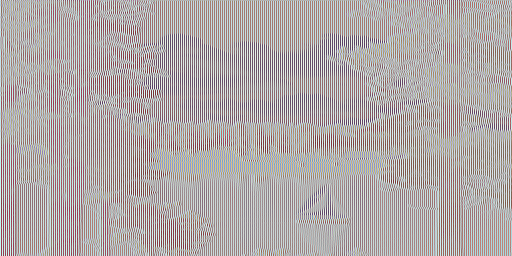

Decoded with 1 measurement(s):


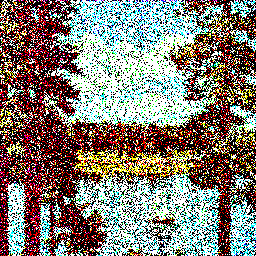

Decoded with 5 measurement(s):


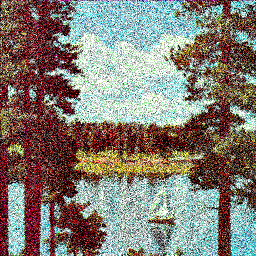

Decoded with 100 measurement(s):


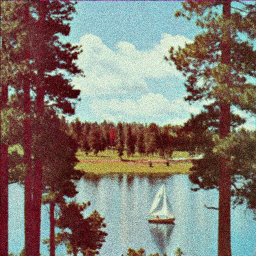

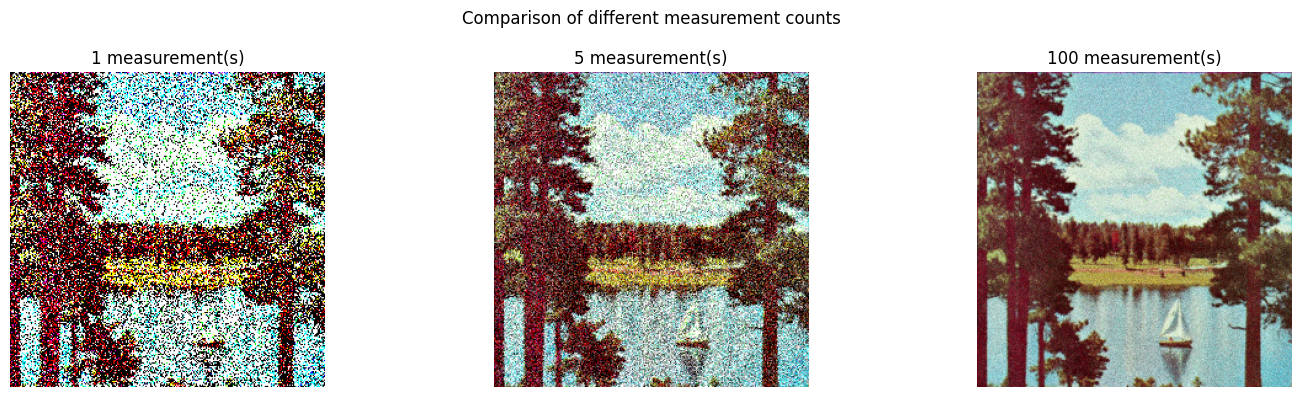

In [26]:
folder_path = "/content/quantum_images/"
png_files = glob.glob(folder_path + "*.png")

# Directly take the first PNG file (ignores checkpoints/hidden files)
img_path = png_files[0]

decode_and_display_quantum_image(img_path, measurement_counts=[1, 5, 100])
